## Module 5 — Building Sequential Workflows in LangGraph

---
### 🏋️ Workflow 1 — BMI Calculator

A simple sequential workflow with no LLMs — pure focus on LangGraph syntax.

**Flow:** `Input (height + weight)` → `calculate_bmi node` → `show result`

**State** has three fields:
- `weight` — given as input
- `height` — given as input
- `bmi` — starts as `None`, gets populated after the calculate node runs

---



#### Step 1 — Define the State

In [1]:

from typing import TypedDict
from langgraph.graph import StateGraph

class BMIState(TypedDict):
    weight: float  # kg
    height: float  # meters
    bmi: float     # calculated output


> 📌 *Always the first step in any LangGraph workflow — define your State as a TypedDict. Every field that any node needs to read or write must live here.*

---

#### Step 2 — Create the Graph Object

In [2]:
graph = StateGraph(BMIState)

> 📌 *`StateGraph` is the core LangGraph class for building workflows. You must pass your State class here so LangGraph knows the shape of data flowing through the graph.*

---

#### Step 3 — Define the Node (Python function)

In [3]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight']
    height = state['height']
    bmi = weight / (height ** 2)
    state['bmi'] = round(bmi, 2)
    return state

> 📌 *Every node is just a Python function. It receives the full State as input, makes its changes, and returns the updated State. The type hints (`BMIState → BMIState`) are good practice — they make the contract explicit.*

---

#### Step 4 — Add Node to Graph

In [4]:
graph.add_node("calculate_bmi", calculate_bmi)

> 📌 *This registers the node with the graph. First argument is the node's name (used when adding edges), second is the Python function behind it. These two names can be different.*

---

#### Step 5 — Add Edges

In [5]:
from langgraph.graph import START, END

graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", END)

> 📌 *`START` and `END` are special dummy nodes built into LangGraph — they mark where the graph begins and terminates. Every graph must have edges connecting to both.*

---

#### Step 6 — Compile

In [6]:
workflow = graph.compile()

> 📌 *Compilation validates the graph structure — checks for orphaned nodes, missing edges, etc. Always do this before invoking. The result is a runnable `workflow` object.*

---

#### Step 7 — Invoke (Execute)

In [7]:
initial_state = {"weight": 80, "height": 1.73}
final_state = workflow.invoke(initial_state)
print(final_state)
# {'weight': 80, 'height': 1.73, 'bmi': 26.73}

{'weight': 80, 'height': 1.73, 'bmi': 26.73}


> 📌 *You always pass an initial State dict to `invoke()`. LangGraph automatically executes nodes in order, passing the evolving State through each one. The final State is returned when execution completes.*

---

#### Step 8 — Visualize the Graph

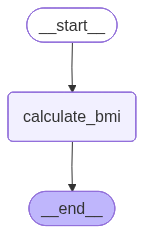

In [8]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

This renders the graph visually in Jupyter Notebook:
```
[START] → [calculate_bmi] → [END]
```

> 💡 *This visualization only works in Jupyter Notebooks — one of the main reasons we use `.ipynb` for this series. As workflows get more complex, visualizing the graph becomes very useful for debugging.*

---

#### 🔑 The LangGraph Workflow Recipe

Every LangGraph workflow you ever build follows this exact sequence:
```
1. Define State       → TypedDict with all data fields
2. Create Graph       → StateGraph(YourState)
3. Define Nodes       → Python functions (state → state)
4. Add Nodes          → graph.add_node(name, function)
5. Add Edges          → graph.add_edge(from, to)
6. Compile            → workflow = graph.compile()
7. Invoke             → workflow.invoke(initial_state)
```

> 📌 *This recipe never changes — only the complexity of the State, nodes, and edges grows as you build more sophisticated workflows.*

---


---

### 🏋️ Workflow 2 — BMI Calculator with Category Label

Extending Workflow 1 by adding a second node that classifies the BMI into a health category. Same sequential structure, just a longer chain.

**Flow:** `START` → `calculate_bmi` → `label_bmi` → `END`

---

#### Updated State

In [9]:
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str  # ← new field added


> 📌 *Whenever you add a new node that produces new data, add the corresponding field to the State first.*

---

#### Nodes

In [10]:

def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight / (height ** 2)
    state['bmi'] = round(bmi, 2)
    return state

def label_bmi(state: BMIState) -> BMIState:
    bmi = state["bmi"]
    if bmi < 18.5:
        state["category"] = "underweight"
    elif bmi < 25:
        state["category"] = "normal"
    elif bmi < 30:
        state["category"] = "overweight"
    else:
        state["category"] = "obese"
    return state


> 📌 *`label_bmi` reads `bmi` from State (set by the previous node) and writes `category` back. This is State passing in action — each node builds on what the previous one left behind.*

---

#### Graph

In [11]:
graph = StateGraph(BMIState)

graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi', label_bmi)

graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_bmi')
graph.add_edge('label_bmi', END)

workflow = graph.compile()

---

#### Run

In [12]:
final_state = workflow.invoke({"weight_kg": 80, "height_m": 1.73})
print(final_state)
# {'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'overweight'}

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'overweight'}


**Visualization:**
```
[START] → [calculate_bmi] → [label_bmi] → [END]
```

---

> 📌 *The key insight from this extension: adding more steps to a sequential workflow is as simple as defining a new function, adding it as a node, and connecting it with edges. The State automatically carries all data forward.*

---



---

### 🤖 Workflow 3 — Simple LLM QA

First workflow that uses an LLM. The goal here isn't complexity — it's learning how LangChain and LangGraph work together.

**Flow:** `START` → `llm_qa` → `END`

---

#### State

In [13]:
class LLMState(TypedDict):
    question: str   # input — the question to ask
    answer: str     # output — LLM's response

---

#### Setup


In [14]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

load_dotenv(override=True)
model = ChatOpenAI()

> 📌 *`load_dotenv()` reads your `.env` file and loads the `OPENAI_API_KEY` into the environment. `ChatOpenAI()` is a LangChain component — this is LangChain and LangGraph working hand in hand.*

---

#### Node

In [15]:
def llm_qa(state: LLMState) -> LLMState:
    question = state["question"]
    prompt = f"Answer the following question:\n{question}"
    response = model.invoke(prompt).content
    state["answer"] = response
    return state

> 📌 *`model.invoke(prompt).content` — `.invoke()` sends the prompt to the LLM and returns a response object. `.content` extracts just the text from it.*

---

#### Graph, Compile & Run

In [16]:
graph = StateGraph(LLMState)
graph.add_node("llm_qa", llm_qa)
graph.add_edge(START, "llm_qa")
graph.add_edge("llm_qa", END)

workflow = graph.compile()

initial_state = {"question": "How far is Moon from the Earth?"}
final_state = workflow.invoke(initial_state)

print(final_state["answer"])

The average distance between the Moon and the Earth is about 238,855 miles (384,400 kilometers).


---

### ✍️ Workflow 4 — Prompt Chaining (Blog Writer)

**Prompt Chaining** = breaking a complex task into a series of LLM calls where each call's output feeds into the next. A single LLM call can't do everything well — so we decompose.

**Flow:** `START` → `create_outline` → `create_blog` → `evaluate_blog` → `END`

---

#### State

In [17]:
class BlogState(TypedDict):
    title: str      # input — blog topic
    outline: str    # generated by create_outline
    content: str    # generated by create_blog
    score: str      # generated by evaluate_blog

> 📌 *Each node adds one more piece to the State. By the end, the State holds the complete picture — title, outline, content, and evaluation.*

---

#### Nodes

In [18]:
def create_outline(state: BlogState) -> BlogState:
    title = state['title']
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    state['outline'] = model.invoke(prompt).content
    return state

def create_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']
    prompt = f'Write a detailed blog on the title - {title} using the following outline\n{outline}'
    state['content'] = model.invoke(prompt).content
    return state

def evaluate_blog(state: BlogState) -> BlogState:
    prompt = f"""Based on the outline:\n{state['outline']}\n
Rate the following blog content:\n{state['content']}\n
Give a score out of 10 with explanation."""
    state["score"] = model.invoke(prompt).content.strip()
    return state


> 📌 *This is the essence of prompt chaining — `create_blog` uses `outline` written by `create_outline`. `evaluate_blog` uses both `outline` and `content`. Each node builds on what previous nodes left in the State.*

---

#### Graph, Compile & Run

In [19]:
graph = StateGraph(BlogState)

graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('evaluate_blog', evaluate_blog)

graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', 'evaluate_blog')
graph.add_edge('evaluate_blog', END)

workflow = graph.compile()

initial_state = {"title": "Rise of AI in India", "outline": "", "content": ""}
final_state = workflow.invoke(initial_state)

In [21]:
print(final_state["outline"])

I. Introduction
    A. Brief overview of AI
    B. Importance of AI in various industries
    C. Introduction to the rise of AI in India

II. History of AI in India
    A. Early developments in AI in India
    B. Growth of AI research in academic institutions
    C. Emergence of AI startups in India

III. Current scenario of AI in India
    A. Adoption of AI in various industries
    B. Government initiatives to promote AI adoption
    C. Challenges faced by the AI industry in India

IV. Growth drivers of AI in India
    A. Increasing demand for automation and efficiency
    B. Availability of skilled AI professionals
    C. Investment in AI research and development

V. Impact of AI on the Indian economy
    A. Job creation and displacement
    B. Potential for economic growth and innovation
    C. Challenges in ensuring inclusive growth

VI. Case studies of AI implementation in India
    A. Healthcare industry
    B. Agriculture sector
    C. Banking and financial services

VII. Futur

In [22]:
print(final_state["content"])

The Rise of AI in India

I. Introduction

A. Artificial Intelligence (AI) is a rapidly evolving technology that involves the development of intelligent machines that can perform tasks that typically require human intelligence. This includes tasks such as visual perception, speech recognition, decision-making, and language translation. 

B. AI has become increasingly important in various industries such as healthcare, finance, agriculture, and manufacturing, where it is used to improve efficiency, productivity, and decision-making. 

C. In recent years, there has been a significant rise in the adoption and development of AI technology in India, with many startups and organizations increasingly incorporating AI into their products and services.

II. History of AI in India

A. India has a long history of AI research and development, with the earliest work dating back to the 1960s. In 1986, the government of India established the Center for Artificial Intelligence and Robotics (CAIR) to pr

In [23]:
print(final_state["score"])

I would give this blog content a score of 9 out of 10. The content is comprehensive, well-structured, and covers various important aspects of AI in India. It provides a good overview of the history, current scenario, growth drivers, impact, case studies, and future trends of AI in India. The information is presented in a clear and engaging manner, making it easy to understand and follow. The only improvement I would suggest is to include more specific data or statistics to further support the points made in the content. Overall, it is a well-written and informative piece on the rise of AI in India.


---

> 📌 *Why decompose into three LLM calls instead of one? Because focused prompts produce better results. An LLM asked only to outline thinks differently than one asked to do everything at once. Each node is an expert at its one job.*

---

